In [1]:
### Hayden Gallo
### 11/5/25
### Bucci Lab

### The goal of this notebook is to be able to implement running a stability analysis on MDSINE2 inference to then inform regime switching for FBA backend.

from typing import *
from pathlib import Path
import itertools
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sb
import numpy as np
import scipy.stats
from statsmodels.stats.multitest import fdrcorrection
import os

import mdsine2 as md2
from mdsine2.names import STRNAMES

from tqdm import tqdm

#import cobra
import reframed
import logging
import json

# Make font editable in AI
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

logging.getLogger("cobra").setLevel(logging.ERROR)


[DEBUG] Using default logger (stdout, stderr).


In [2]:
### here define the jacobain function


def linstability_get_steadystates_and_eigenvalues(end_profile, start_profile, Beta, alpha):
    """
    Python/Numpy port of Vanni Bucci's MATLAB function:
    linstability_get_steadystates_and_eigenvalues.m
 
    Parameters
    ----------
    end_profile : array_like of bool/int (shape: n,)
        Indicator of taxa present in the final (steady) profile.
    start_profile : array_like of bool/int (shape: n,)
        Indicator of taxa present in the starting profile.
    Beta : array_like (shape: n, n)
        Interaction matrix (gLV A or Beta).
    alpha : array_like (shape: n,)
        Intrinsic growth vector.
 
    Returns
    -------
    eigvals : np.ndarray (shape: m,) or np.ndarray([np.nan])
        Eigenvalues of the Jacobian at the steady state restricted to the
        start_profile subspace. If the Jacobian/eigendecomposition fails,
        returns array([np.nan]).
    fss : np.ndarray (shape: n,)
        Full steady-state vector (zeros where end_profile==0), with
        fss[end_profile] = - Beta_2^{-1} * alpha_2.
    alpha_1 : np.ndarray (shape: m,)
        alpha restricted to start_profile.
    Beta_1 : np.ndarray (shape: m, m)
        Beta restricted to start_profile x start_profile.
 
    Notes
    -----
    - Uses a linear solve instead of explicit matrix inversion.
    - Replicates MATLAB’s indexing and Jacobian construction.
    """
    # Ensure numpy arrays and boolean masks
    end_profile   = np.asarray(end_profile).astype(bool)
    start_profile = np.asarray(start_profile).astype(bool)
    Beta  = np.asarray(Beta, dtype=float)
    alpha = np.asarray(alpha, dtype=float)
 
    # Reduced matrices/vectors on start_profile
    Beta_1  = Beta[np.ix_(start_profile, start_profile)]
    alpha_1 = alpha[start_profile]
 
    # Steady state on the intersection of start & end
    in_both = start_profile & end_profile
    Beta_2  = Beta[np.ix_(in_both, in_both)]
    alpha_2 = alpha[in_both]
 
    # fss initialized to zeros, then fill only where end_profile is True
    fss = np.zeros_like(alpha)
    try:
        # Solve Beta_2 * x = -alpha_2  →  x = -solve(Beta_2, alpha_2)
        if Beta_2.size > 0:
            fss[in_both] = -np.linalg.solve(Beta_2, alpha_2)
    except np.linalg.LinAlgError:
        # Singular or ill-conditioned; leave fss as is (zeros), continue
        pass
 
    # fss restricted to start_profile
    fss2 = fss[start_profile]
 
    # Build Jacobian on the start_profile subspace (matches MATLAB loops)
    m = Beta_1.shape[0]
    Jacobian_matrix = np.zeros((m, m), dtype=float)
 
    # Precompute row-wise sums Beta_1[i, :] * fss2 (dot product)
    row_dot = Beta_1 @ fss2  # shape (m,)
 
    for im in range(m):
        for jm in range(m):
            if im == jm:
                # alpha_1(i) + Beta_1(i,i)*fss2(i) + sum_k Beta_1(i,k)*fss2(k)
                Jacobian_matrix[im, jm] = alpha_1[im] + Beta_1[im, im] * fss2[im] + row_dot[im]
            else:
                # Beta_1(i,j) * fss2(i)
                Jacobian_matrix[im, jm] = Beta_1[im, jm] * fss2[im]
 
    # Eigenvalues of Jacobian
    try:
        eigvals = np.linalg.eigvals(Jacobian_matrix)
    except np.linalg.LinAlgError:
        eigvals = np.array([np.nan])
 
    return eigvals, fss, alpha_1, Beta_1

    

In [3]:
print(os.getcwd())

/Users/haydengallo/UMass_Dropbox/UMass Medical School Dropbox/Hayden Gallo/Bucci_Lab/glv_FBA/glv_dfba_code


In [4]:
data_dir = Path('/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/processed_data_filtered_RC_all_cohorts_corrected_abs_abun/merged_studies_fixed_cluster_100_its_daily')


In [5]:
### load the mcmc pkl

pkl_path = data_dir / "mcmc.pkl"


mcmc = md2.BaseMCMC.load(str(pkl_path))

mcmc


In [6]:
if mcmc.graph.perturbations is not None:
            perturbations = []
            perturbations_start = []
            perturbations_end = []
            for pert in mcmc.graph.perturbations:
                #logger.info('Loading perturbation `{}`'.format(pert.name))
                pert_value = pert.get_trace_from_disk()
                pert_value[np.isnan(pert_value)] = 0.

                perturbations.append(pert_value)
                #perturbations_start.append(pert.starts[subj_name])
                #perturbations_end.append(pert.ends[subj_name])

In [7]:
mean_perturbations = pd.DataFrame(np.median(perturbations[0], axis =0))
mean_perturbations.to_csv('median_perturbations_test.csv')


In [8]:
mean_perturbations

,0
0,0.000000
1,19.055170
2,0.000000
3,-17.600262
4,-3.423362
5,-5.322719
6,-17.885449
7,0.000000
8,0.000000
9,0.438195


In [9]:
self_interactions = mcmc.graph[STRNAMES.SELF_INTERACTION_VALUE].get_trace_from_disk(section='posterior')

In [10]:
interactions = mcmc.graph[STRNAMES.INTERACTIONS_OBJ].get_trace_from_disk(section='posterior')



interactions[np.isnan(interactions)] = 0

self_interactions = mcmc.graph[STRNAMES.SELF_INTERACTION_VALUE].get_trace_from_disk(section='posterior')
self_interactions = -np.absolute(self_interactions)

for i in range(self_interactions.shape[1]):
    interactions[:, i, i] = self_interactions[:, i]

interactions

array([[[-1.67015551e-10,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00, -2.10162628e-09,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00, -5.64368088e-11, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        ...,
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         -4.27707077e-09,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00, -1.27748436e-09,  0.00000000e+00, ...,
          0.00000000e+00, -4.41554842e-10, -1.36963351e-09],
        [ 0.00000000e+00,  0.00000000e+00, -1.07870961e-10, ...,
          0.00000000e+00,  5.68711967e-10, -1.37526965e-09]],

       [[-2.26720175e-10,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00, -2.05314753e-09,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e

In [11]:
mean_interactions = pd.DataFrame(np.median(interactions, axis = 0))
mean_interactions.to_csv('median_interactions.csv')
mean_interactions

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,-8.477004e-11,-2.160624e-10,0.000000e+00,-1.048540e-10,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-5.878523e-12,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
1,0.000000e+00,-5.374540e-10,0.000000e+00,-4.184801e-10,0.000000e+00,0.000000e+00,0.000000e+00,-1.969858e-11,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
2,0.000000e+00,-1.550154e-10,-7.158717e-11,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
3,0.000000e+00,-1.932493e-10,0.000000e+00,-2.518275e-10,0.000000e+00,0.000000e+00,0.000000e+00,-3.653263e-11,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
4,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-1.038827e-10,0.000000e+00,-2.087336e-11,0.000000e+00,0.000000e+00,0.000000e+00,-7.915612e-12,0.000000e+00,0.000000e+00,0.000000e+00,-2.750721e-10
5,0.000000e+00,-1.670633e-10,0.000000e+00,0.000000e+00,0.000000e+00,-3.649609e-11,0.000000e+00,1.419976e-10,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
6,0.000000e+00,-2.020314e-10,-1.100245e-11,0.000000e+00,0.000000e+00,0.000000e+00,-1.567423e-10,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
7,0.000000e+00,0.000000e+00,-1.308157e-11,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-1.809141e-10,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
8,0.000000e+00,-2.977366e-10,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-2.201026e-11,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
9,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-1.301216e-11,-8.445089e-11,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00


In [12]:
growths = mcmc.graph[STRNAMES.GROWTH_VALUE].get_trace_from_disk(section='posterior')
growths.shape

(50, 15)

In [13]:
mean_growth = pd.DataFrame(np.median(growths, axis=0))
mean_growth.to_csv('median_grow.csv')
mean_growth

,0
0,0.853156
1,0.286396
2,0.677629
3,0.107605
4,0.411613
5,0.816877
6,0.131971
7,0.208037
8,0.460171
9,0.130768


In [14]:
abun_df = pd.read_csv('/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/processed_data_filtered_RC_all_cohorts_corrected_abs_abun/merged_studies_fixed_cluster_100_its_daily/posterior/filtering/Subject_1953/mean.tsv', sep='\t', index_col=0)
abun_df.head()

,-3.0,-2.0,-1.0,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0
14ac4eaad5b4e2ff3c071832e0fd4229,4.607321e+08,8.070274e+07,3.524221e+07,6.506250e+08,2.550231e+09,2.101804e+09,4.641726e+06,7.585718e+05,2.028617e+05,5.436567e+06,3.014597e+06,5.776370e+07,5.218594e+07,1.720574e+08,2.225538e+09,4.392619e+08,1.842532e+08,2.076124e+09
18673193aa6bf30c6a1e71ac504e04df,3.373055e+02,3.298558e+02,8.585188e+04,1.116701e+09,5.435858e+09,1.400934e+10,4.133705e+06,2.219934e+08,1.044084e+08,1.331538e+07,6.676420e+07,8.508135e+06,4.744236e+06,2.600540e+05,9.880968e+06,7.106709e+05,1.979406e+06,3.923428e+07
320dfd16200daaf2b0503975d4e68fd5,1.811553e+08,6.760076e+07,3.052622e+07,6.854094e+08,3.564536e+09,1.146710e+09,1.488476e+07,1.541137e+07,1.187678e+08,2.629453e+09,9.656763e+09,2.042217e+09,6.797580e+08,7.143532e+08,6.466692e+08,7.101714e+08,3.308470e+09,8.603251e+09
36173253c63ad49abc12361a0b3304eb,5.712346e+09,1.134918e+09,6.312476e+07,8.059682e+05,5.107799e+03,1.117033e+03,4.207931e+01,1.142881e+04,1.164051e+07,1.916092e+08,2.813750e+09,8.372230e+08,5.929453e+07,9.876773e+07,7.150691e+07,2.354005e+08,8.925314e+08,8.432027e+08
391821255f31ef94686927f4fba6fbc3,3.422313e+09,3.588348e+08,1.334050e+07,1.866648e+06,1.616974e+06,3.018640e+04,8.529819e+03,6.442859e+01,5.216161e+01,1.234393e+05,2.893738e+07,7.903891e+08,7.410093e+08,5.005327e+08,1.382213e+09,1.350705e+10,2.635707e+09,8.190795e+09


In [135]:
smoothed_abun_df = pd.read_csv('/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/processed_data_filtered_RC_all_cohorts_corrected_abs_abun/filtering_hourly_resolution/Subject_1999/mean_smoothed.tsv',sep='\t', index_col=0)
smoothed_abun_df.head()

,-3.0,-2.9583333333333335,-2.916666666666667,-2.8750000000000004,-2.833333333333334,-2.7916666666666674,-2.750000000000001,-2.7083333333333344,-2.666666666666668,-2.6250000000000013,...,13.62499999999994,13.666666666666607,13.708333333333275,13.74999999999994,13.791666666666607,13.833333333333272,13.87499999999994,13.916666666666607,13.958333333333272,14.0
14ac4eaad5b4e2ff3c071832e0fd4229,2.533138e+08,2.780380e+08,3.016429e+08,3.235821e+08,3.433487e+08,3.604964e+08,3.746571e+08,3.855545e+08,3.930119e+08,3.969548e+08,...,1.070847e+09,1.095900e+09,1.122103e+09,1.149491e+09,1.178099e+09,1.207961e+09,1.239111e+09,1.271585e+09,1.305417e+09,1.340639e+09
18673193aa6bf30c6a1e71ac504e04df,1.095657e+03,9.259829e+02,7.868884e+02,6.723548e+02,5.776331e+02,4.989608e+02,4.333447e+02,3.783948e+02,3.321947e+02,2.932019e+02,...,2.747688e+02,2.695337e+02,2.640003e+02,2.581798e+02,2.520849e+02,2.457300e+02,2.391312e+02,2.323060e+02,2.252737e+02,2.180546e+02
320dfd16200daaf2b0503975d4e68fd5,1.490341e+09,1.339589e+09,1.202303e+09,1.077644e+09,9.647552e+08,8.627785e+08,7.708699e+08,6.882094e+08,6.140091e+08,5.475196e+08,...,3.107831e+09,3.234246e+09,3.366276e+09,3.504031e+09,3.647599e+09,3.797052e+09,3.952436e+09,4.113769e+09,4.281041e+09,4.454205e+09
36173253c63ad49abc12361a0b3304eb,5.264788e+08,5.686839e+08,6.083128e+08,6.445988e+08,6.768572e+08,7.045090e+08,7.270981e+08,7.443029e+08,7.559412e+08,7.619696e+08,...,3.887003e+09,4.508674e+09,5.268138e+09,6.201606e+09,7.356220e+09,8.793742e+09,1.059563e+10,1.287002e+10,1.576151e+10,1.946475e+10
391821255f31ef94686927f4fba6fbc3,7.162489e+07,1.026539e+08,1.437429e+08,1.967578e+08,2.634177e+08,3.451089e+08,4.426840e+08,5.562681e+08,6.850954e+08,8.274013e+08,...,6.784824e+09,7.042053e+09,7.314477e+09,7.602969e+09,7.908449e+09,8.231889e+09,8.574311e+09,8.936793e+09,9.320465e+09,9.726516e+09


In [136]:
np.max(smoothed_abun_df.sum(axis=0))

92201135235.90752

In [111]:
abun_array = np.array(smoothed_abun_df).T

In [112]:
abun_array.shape

(416, 15)

In [113]:
interactions.shape

(50, 15, 15)

In [114]:
import numpy as np
from numpy.linalg import eig, inv

# Example data
T = 416     # time points
L = 15        # species
K = 50      # MCMC samples

# Simulated abundances (could be from your gLV simulation)
#X = np.abs(np.random.randn(T, L))  # shape (T, L)

# Simulated MCMC samples for alpha and beta
#alpha_samples = np.random.randn(K, L) * 0.1
#beta_samples = np.random.randn(K, L, L) * 0.05
#for k in range(K):
#    np.fill_diagonal(beta_samples[k], -0.1 + np.random.randn(L) * 0.1)  # ensure self-limiting

# Convert to relative abundance per time point
rel_abun = abun_array / abun_array.sum(axis=1, keepdims=True)

# Relative abundance threshold (e.g. 0.1%)
epsilon = 1e-2


# Threshold to determine presence/absence
#epsilon = 1e8

# Storage for stability probabilities
P_stable = np.zeros(T)

for t in range(T):
    #active = np.where(abun_array[t, :] > epsilon)[0]
    active = np.where(rel_abun[t, :] > epsilon)[0]

    if len(active) == 0:
        P_stable[t] = np.nan
        continue

    stable_count = 0

    for k in range(K):
        α = growths[k, active]
        β = interactions[k][np.ix_(active, active)]

        try:
            # Compute steady state for this subcommunity
            x_star = -inv(β) @ α

            # Skip invalid (negative) steady states
            if np.any(x_star <= 0):
                continue

            # Compute Jacobian at steady state
            J = np.diag(x_star) @ β

            # Check eigenvalues
            eigvals = eig(J)[0]
            if np.all(np.real(eigvals) < 0):
                stable_count += 1
                print('yes')
        except np.linalg.LinAlgError:
            # Skip if β is singular
            continue

    P_stable[t] = stable_count / K

print("Stability probability at each time point:")
print(P_stable)


yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes
yes


In [115]:
indexes = np.where(P_stable > .9)[0]
indexes

array([140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152,
       153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165,
       166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178,
       179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191,
       192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204,
       205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216])

In [116]:
P_stable

array([0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.02, 0.02, 0.08, 0.08,
       0.08, 0.08, 0.08, 0.08, 0.08, 0.16, 0.16, 0.16, 0.16, 0.16, 0.5 ,
       0.36, 0.36, 0.36, 0.36, 0.36, 0.36, 0.36, 0.36, 0.36, 0.36, 0.36,
       0.36, 0.36, 0.36, 0.12, 0.12, 0.12, 0.12, 0.12, 0.  , 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.08, 0.08, 0.08, 0.1 , 0.14,
       0.14, 0.14, 0.14, 0.14, 0.14, 0.1 , 0.1 , 0.  , 0.  , 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.1 ,
       0.44, 0.06, 0.44, 0.44, 0.44, 0.74, 0.74, 0.74, 0.74, 0.74, 0.74,
       0.74, 0.74, 0.74, 0.74, 0.74, 0.82, 0.82, 0.82, 1.  , 1.  , 1.  ,
       1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.

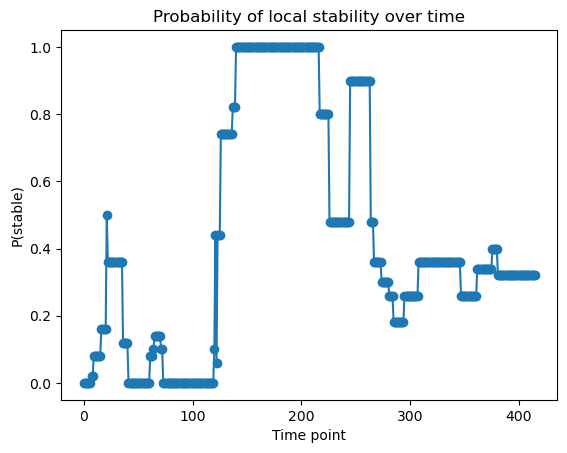

In [117]:
import matplotlib.pyplot as plt

plt.plot(range(T), P_stable, marker='o')
plt.xlabel('Time point')
plt.ylabel('P(stable)')
plt.title('Probability of local stability over time')
plt.show()


In [118]:
n_species = 15
n_timepoints = 416
n_samples = 50


In [119]:
abun_df

,-3.0,-2.0,-1.0,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,11.0,12.0,13.0,14.0
14ac4eaad5b4e2ff3c071832e0fd4229,4.607321e+08,8.070274e+07,3.524221e+07,6.506250e+08,2.550231e+09,2.101804e+09,4.641726e+06,7.585718e+05,2.028617e+05,5.436567e+06,3.014597e+06,5.776370e+07,5.218594e+07,1.720574e+08,2.225538e+09,4.392619e+08,1.842532e+08,2.076124e+09
18673193aa6bf30c6a1e71ac504e04df,3.373055e+02,3.298558e+02,8.585188e+04,1.116701e+09,5.435858e+09,1.400934e+10,4.133705e+06,2.219934e+08,1.044084e+08,1.331538e+07,6.676420e+07,8.508135e+06,4.744236e+06,2.600540e+05,9.880968e+06,7.106709e+05,1.979406e+06,3.923428e+07
320dfd16200daaf2b0503975d4e68fd5,1.811553e+08,6.760076e+07,3.052622e+07,6.854094e+08,3.564536e+09,1.146710e+09,1.488476e+07,1.541137e+07,1.187678e+08,2.629453e+09,9.656763e+09,2.042217e+09,6.797580e+08,7.143532e+08,6.466692e+08,7.101714e+08,3.308470e+09,8.603251e+09
36173253c63ad49abc12361a0b3304eb,5.712346e+09,1.134918e+09,6.312476e+07,8.059682e+05,5.107799e+03,1.117033e+03,4.207931e+01,1.142881e+04,1.164051e+07,1.916092e+08,2.813750e+09,8.372230e+08,5.929453e+07,9.876773e+07,7.150691e+07,2.354005e+08,8.925314e+08,8.432027e+08
391821255f31ef94686927f4fba6fbc3,3.422313e+09,3.588348e+08,1.334050e+07,1.866648e+06,1.616974e+06,3.018640e+04,8.529819e+03,6.442859e+01,5.216161e+01,1.234393e+05,2.893738e+07,7.903891e+08,7.410093e+08,5.005327e+08,1.382213e+09,1.350705e+10,2.635707e+09,8.190795e+09
3936cc515320e9f29d81ffeaa92718e8,8.162938e+01,3.584523e+03,1.092322e+02,7.064673e+00,1.102804e+02,3.694986e+01,1.453159e+01,7.064380e+01,4.086744e+03,4.576634e+06,3.698987e+06,1.322378e+08,5.708926e+08,1.554469e+09,8.307428e+08,1.314857e+09,1.632570e+08,2.088536e+09
3e741fc097143bb6782af5233cb7af98,2.447585e+09,1.331511e+09,3.696727e+06,4.318627e+05,8.710186e+04,4.366857e+04,5.254969e+02,2.482786e+02,4.931956e+02,2.044293e+03,1.186584e+03,1.439287e+01,1.290061e+02,1.588332e+04,2.708906e+05,2.535520e+06,1.097233e+07,2.833539e+08
4cc9a4b9aaa3ee9a5c14cc27551a6844,1.251566e+05,4.738778e+04,5.214972e+03,9.493164e+03,1.162261e+06,2.814558e+08,6.116931e+08,2.223042e+09,1.193476e+10,8.094757e+08,2.307285e+09,4.117828e+07,6.086453e+07,1.226103e+07,1.296707e+07,1.140561e+06,1.745782e+06,2.572283e+04
795b6ba45f502a00b24b212278991c63,2.351717e+09,8.701077e+10,6.077116e+09,4.880463e+08,6.967543e+07,1.226165e+07,3.736866e+04,5.208059e+04,5.833910e+03,6.721670e+03,1.073988e+03,3.682204e+02,6.992288e+02,1.075661e+03,2.637091e+03,4.493323e+02,6.982135e+01,4.284306e+02
7ca7ca8214441730c2437d1f53390cdb,4.973107e+09,1.797371e+10,3.814989e+09,4.012719e+09,6.958280e+08,2.615635e+08,3.992699e+09,5.265523e+09,2.286496e+10,3.495923e+09,1.045747e+10,1.114152e+09,3.344690e+09,6.493573e+09,1.345488e+10,1.097117e+09,4.931338e+09,1.212126e+10


In [120]:
abun_df_filt = smoothed_abun_df.copy()
rel_abun_filt = rel_abun.copy()

abun_df_filt[abun_df_filt < 1e8] = 0
abun_df_filt[abun_df_filt > 1e8] = 1

rel_abun_filt[rel_abun_filt < epsilon] = 0
rel_abun_filt[rel_abun_filt > epsilon] = 1

#

In [121]:
abun_array_filt = np.array(abun_df_filt).T
abun_array_filt

array([[1., 0., 1., ..., 1., 1., 0.],
       [1., 0., 1., ..., 1., 1., 0.],
       [1., 0., 1., ..., 1., 1., 0.],
       ...,
       [1., 0., 1., ..., 0., 1., 0.],
       [1., 0., 1., ..., 0., 1., 0.],
       [1., 0., 1., ..., 0., 1., 0.]])

In [122]:
interactions.shape

(50, 15, 15)

In [123]:
def stability_analysis_main(abun_df, int_matrix, growth_rates, abun_tol, prob_tol):

    ### calculate the number of species and the number of timepoints from the input abun_averaged_smoothed_abun matrix

    num_species = abun_df.shape[0]
    n_timepoints = abun_df.shape[1]
    n_samples = int_matrix.shape[0]

    stability_prob = np.zeros(n_timepoints)


    ### convert to relative abundance
    abun_array = np.array(abun_df).T
    rel_abun = abun_array / abun_array.sum(axis=1, keepdims=True)

    ### based on filtering criteria remove very small species

    rel_abun[rel_abun < abun_tol] = 0
    rel_abun[rel_abun > abun_tol] = 1

    for t in range(n_timepoints):
        #start_profile = abun_array_filt[t]
        #end_profile = abun_array_filt[t]  # assume same for simplicity

        start_profile = rel_abun[t]
        end_profile = rel_abun[t]  # assume same for simplicity
        
        stable_count = 0
        for i in range(n_samples):
            
            alpha = growth_rates[i]
            Beta = int_matrix[i]
            eigvals = linstability_get_steadystates_and_eigenvalues(end_profile, start_profile, Beta, alpha)
            if np.all(np.real(eigvals) < 0):
                stable_count += 1
        
        stability_prob[t] = stable_count / n_samples
        stable_t_points = np.where(stability_prob > prob_tol)[0]


    return stability_prob, stable_t_points


    

In [124]:
def linstability_get_steadystates_and_eigenvalues(end_profile, start_profile, Beta, alpha):
    end_profile   = np.asarray(end_profile).astype(bool)
    start_profile = np.asarray(start_profile).astype(bool)
    Beta  = np.asarray(Beta, dtype=float)
    alpha = np.asarray(alpha, dtype=float)

    Beta_1  = Beta[np.ix_(start_profile, start_profile)]
    alpha_1 = alpha[start_profile]
    in_both = start_profile & end_profile
    Beta_2  = Beta[np.ix_(in_both, in_both)]
    alpha_2 = alpha[in_both]

    fss = np.zeros_like(alpha)
    try:
        if Beta_2.size > 0:
            fss[in_both] = -np.linalg.solve(Beta_2, alpha_2)
    except np.linalg.LinAlgError:
        pass

    fss2 = fss[start_profile]
    m = Beta_1.shape[0]
    Jacobian_matrix = np.zeros((m, m), dtype=float)
    row_dot = Beta_1 @ fss2
    for im in range(m):
        for jm in range(m):
            if im == jm:
                Jacobian_matrix[im, jm] = alpha_1[im] + Beta_1[im, im]*fss2[im] + row_dot[im]
            else:
                Jacobian_matrix[im, jm] = Beta_1[im, jm]*fss2[im]

    try:
        eigvals = np.linalg.eigvals(Jacobian_matrix)
    except np.linalg.LinAlgError:
        eigvals = np.array([np.nan])
    return eigvals


In [125]:
stability_prob = np.zeros(n_timepoints)

for t in range(n_timepoints):
    #start_profile = abun_array_filt[t]
    #end_profile = abun_array_filt[t]  # assume same for simplicity

    start_profile = rel_abun_filt[t]
    end_profile = rel_abun_filt[t]  # assume same for simplicity
    
    stable_count = 0
    for i in range(n_samples):
        #print(i)
        alpha = growths[i]
        Beta = interactions[i]
        eigvals = linstability_get_steadystates_and_eigenvalues(end_profile, start_profile, Beta, alpha)
        if np.all(np.real(eigvals) < 0):
            stable_count += 1
    
    stability_prob[t] = stable_count / n_samples
    

print("P_stable(t):", np.round(stability_prob, 3))


P_stable(t): [0.   0.   0.   0.   0.   0.   0.   0.02 0.02 0.08 0.08 0.08 0.08 0.08
 0.08 0.08 0.16 0.16 0.16 0.16 0.16 0.5  0.36 0.36 0.36 0.36 0.36 0.36
 0.36 0.36 0.36 0.36 0.36 0.36 0.36 0.36 0.12 0.12 0.12 0.12 0.12 0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.08 0.08 0.08 0.1  0.14 0.14 0.14 0.14 0.14
 0.14 0.1  0.1  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.1  0.44 0.06 0.44 0.44 0.44
 0.74 0.74 0.74 0.74 0.74 0.74 0.74 0.74 0.74 0.74 0.74 0.82 0.82 0.82
 1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.
 1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.
 1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.
 1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.   1.
 1.   1.   

In [126]:
len(np.linspace(0,17,416))

416

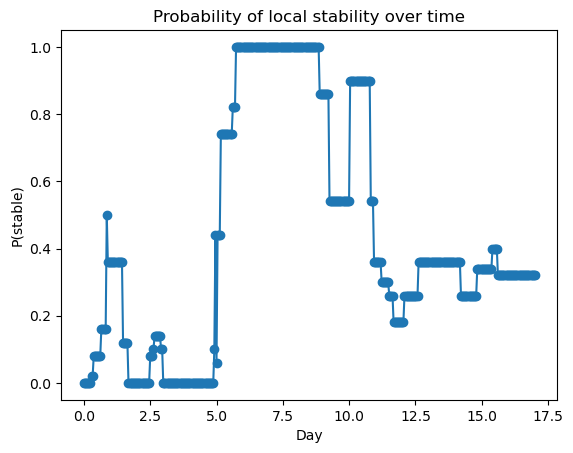

In [127]:
plt.plot(np.linspace(0,17,416), stability_prob, marker='o')
plt.xlabel('Day')
plt.ylabel('P(stable)')
plt.title('Probability of local stability over time')
plt.show()


In [128]:
stability_prob

array([0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.02, 0.02, 0.08, 0.08,
       0.08, 0.08, 0.08, 0.08, 0.08, 0.16, 0.16, 0.16, 0.16, 0.16, 0.5 ,
       0.36, 0.36, 0.36, 0.36, 0.36, 0.36, 0.36, 0.36, 0.36, 0.36, 0.36,
       0.36, 0.36, 0.36, 0.12, 0.12, 0.12, 0.12, 0.12, 0.  , 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.08, 0.08, 0.08, 0.1 , 0.14,
       0.14, 0.14, 0.14, 0.14, 0.14, 0.1 , 0.1 , 0.  , 0.  , 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ,
       0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.1 ,
       0.44, 0.06, 0.44, 0.44, 0.44, 0.74, 0.74, 0.74, 0.74, 0.74, 0.74,
       0.74, 0.74, 0.74, 0.74, 0.74, 0.82, 0.82, 0.82, 1.  , 1.  , 1.  ,
       1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.  , 1.

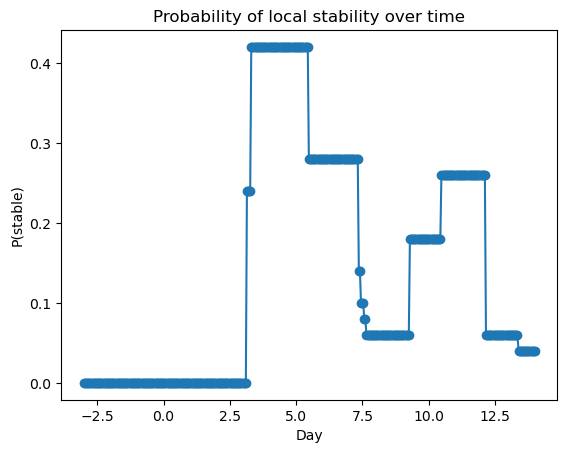

In [129]:
test, stable_t_points = stability_analysis_main(smoothed_abun_df, interactions, growths, .0001, .9)

plt.plot(np.linspace(-3,14,416), test, marker='o')
plt.xlabel('Day')
plt.ylabel('P(stable)')
plt.title('Probability of local stability over time')
plt.show()

In [130]:
stable_t_points

array([], dtype=int64)

In [2]:

cobra_models_dir = Path('/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/processed_data_filtered_RC_all_cohorts_corrected_abs_abun/test_draft_reconstructions_07_08_25')

# Make the data and validation Study objects
cobra_models = sorted(cobra_models_dir.glob('*.sbml'))
cobra_models = {f.stem : f for f in cobra_models}

### Just loading the models needed in 

loaded_models = {}

#count = 0

for key in cobra_models:
    #if count == 1:
    #    break
    #print(key.split('_'))
    model_name = key.split('_')[0] + '_' + key.split('_')[1]
    print(model_name)
    model = cobra.io.read_sbml_model(cobra_models[key])
    loaded_models[model_name] = model
    #count+=1

# Adding correct names to refseq_to_agora_df

temp_name_list = []

'''
for i in range(0, len(refseq_to_agora_df)):
    #print(refseq_to_agora_df['Agora_Name'].iloc[i].split('_'))
    temp_name = refseq_to_agora_df['Agora_Name'].iloc[i].replace('.',"_")
    print(temp_name)
    temp_name_list.append(temp_name.split('_')[0] + '_' + temp_name.split('_')[1])

refseq_to_agora_df['Model_Names'] = temp_name_list


### Manual renaming of two lactobacilllus species ###
#refseq_to_agora_df.loc['320dfd16200daaf2b0503975d4e68fd5','Model_Names'] = 'Lactobacillus_reuteri'
#refseq_to_agora_df.loc['94e30534f622e456a683abe4e60fc214','Model_Names'] = 'Lactobacillus_animalis'
#refseq_to_agora_df.loc['18673193aa6bf30c6a1e71ac504e04df','Model_Names'] = 'Staphylococcus_equorum'
#refseq_to_agora_df.loc['18673193aa6bf30c6a1e71ac504e04df','Agora_Name'] = 'Staphylococcus_equorum_subsp_equorum_Mu2'

#refseq_to_agora_df

ASV_string_to_species_names_dict = dict(zip(refseq_to_agora_df.index.tolist(), refseq_to_agora_df['Model_Names']))

models_for_FBA = {}

for i in refseq_to_agora_df.index.tolist():
    models_for_FBA[i] = loaded_models[refseq_to_agora_df.loc[i]['Model_Names']].copy()
    #models_for_FBA[i] = refseq_to_agora_df.loc[i]['Model_Names']
'''

Bacteroides_caecimuris
Bifidobacterium_pseudolongum
Duncaniealla_sp
Enterococcus_faecalis
Erysipelotrichaceae_sp
Jeotgalicoccus_nanhaiensis
Lactobacillus_gasseri
Lactobacillus_intestinalis
Lactobacillus_murinus
Lactobacillus_reuteri
Merdibacter_massiliensis
Muribaculum_intestinale
Ruminococcus_bicirculans
Staphylococcus_LKG31
Turicibacter_sp


'\nfor i in range(0, len(refseq_to_agora_df)):\n    #print(refseq_to_agora_df[\'Agora_Name\'].iloc[i].split(\'_\'))\n    temp_name = refseq_to_agora_df[\'Agora_Name\'].iloc[i].replace(\'.\',"_")\n    print(temp_name)\n    temp_name_list.append(temp_name.split(\'_\')[0] + \'_\' + temp_name.split(\'_\')[1])\n\nrefseq_to_agora_df[\'Model_Names\'] = temp_name_list\n\n\n### Manual renaming of two lactobacilllus species ###\n#refseq_to_agora_df.loc[\'320dfd16200daaf2b0503975d4e68fd5\',\'Model_Names\'] = \'Lactobacillus_reuteri\'\n#refseq_to_agora_df.loc[\'94e30534f622e456a683abe4e60fc214\',\'Model_Names\'] = \'Lactobacillus_animalis\'\n#refseq_to_agora_df.loc[\'18673193aa6bf30c6a1e71ac504e04df\',\'Model_Names\'] = \'Staphylococcus_equorum\'\n#refseq_to_agora_df.loc[\'18673193aa6bf30c6a1e71ac504e04df\',\'Agora_Name\'] = \'Staphylococcus_equorum_subsp_equorum_Mu2\'\n\n#refseq_to_agora_df\n\nASV_string_to_species_names_dict = dict(zip(refseq_to_agora_df.index.tolist(), refseq_to_agora_df[\'Mode

In [5]:
loaded_models['Bacteroides_caecimuris'].reactions.get_by_id(id='bio1').lb = -1000

In [6]:
loaded_models['Enterococcus_faecalis'].slim_optimize()

41.10443404387602

In [7]:
from pathlib import Path
from reframed import load_cbmodel
from reframed.solvers import solver

#sbml_dir = Path("kbase_sbmls")

models = []
for f in cobra_models_dir.glob("*.sbml"):
    m = load_cbmodel(str(f), load_metadata=False, flavor='cobra')
    m.id = f.stem          # clean species ID
    models.append(m)

print("Loaded species:", [m.id for m in models])


/Users/haydengallo/anaconda3/envs/cobra_cplex/lib/python3.10/site-packages/reframed/io/sbml.py:173: UserWarning: Exchange reactions were not detected.
  warn("Exchange reactions were not detected.")


Loaded species: ['Turicibacter_sp_GCF_037014675.1.fna_assembly.RAST.mdl', 'Lactobacillus_gasseri_GCF_000177415.1_ASM17741v1_genomic.fna_assembly.RAST.mdl', 'Lactobacillus_murinus_GCF_003288115.1.fna_assembly.RAST.mdl', 'Staphylococcus_LKG31_GCF_048568385.1.fna_assembly.RAST.mdl', 'Muribaculum_intestinale_GCF_001688845.2.fna_assembly.RAST.mdl', 'Bacteroides_caecimuris_GCF_001688725.2.fna_assembly.RAST.mdl', 'Bifidobacterium_pseudolongum_GCF_000771225.1_DSM-20099_genomic.fna_assembly.RAST.mdl', 'Erysipelotrichaceae_sp_GCA_030582615.1.fna_assembly.RAST.mdl', 'Lactobacillus_intestinalis_GCF_001435325.1.fna_assembly.RAST.mdl', 'Duncaniealla_sp_GCF_005304985.1.fna_assembly.RAST.mdl', 'Ruminococcus_bicirculans_GCF_000723465.1.fna_assembly.RAST.mdl', 'Merdibacter_massiliensis_GCF_900155395.1_PRJEB18752_genomic.fna_assembly.RAST.mdl', 'Lactobacillus_reuteri_GCF_000236455.2_ASM23645v2_genomic.fna_assembly.RAST.mdl', 'Enterococcus_faecalis_GCF_000393355.1.fna_assembly.RAST.mdl', 'Jeotgalicoccus_n

In [8]:
for m in models:
    print(m.id, m.biomass_reaction)


Turicibacter_sp_GCF_037014675.1.fna_assembly.RAST.mdl bio1
Lactobacillus_gasseri_GCF_000177415.1_ASM17741v1_genomic.fna_assembly.RAST.mdl bio1
Lactobacillus_murinus_GCF_003288115.1.fna_assembly.RAST.mdl bio1
Staphylococcus_LKG31_GCF_048568385.1.fna_assembly.RAST.mdl bio1
Muribaculum_intestinale_GCF_001688845.2.fna_assembly.RAST.mdl bio1
Bacteroides_caecimuris_GCF_001688725.2.fna_assembly.RAST.mdl bio1
Bifidobacterium_pseudolongum_GCF_000771225.1_DSM-20099_genomic.fna_assembly.RAST.mdl bio1
Erysipelotrichaceae_sp_GCA_030582615.1.fna_assembly.RAST.mdl bio1
Lactobacillus_intestinalis_GCF_001435325.1.fna_assembly.RAST.mdl bio1
Duncaniealla_sp_GCF_005304985.1.fna_assembly.RAST.mdl bio1
Ruminococcus_bicirculans_GCF_000723465.1.fna_assembly.RAST.mdl bio1
Merdibacter_massiliensis_GCF_900155395.1_PRJEB18752_genomic.fna_assembly.RAST.mdl bio1
Lactobacillus_reuteri_GCF_000236455.2_ASM23645v2_genomic.fna_assembly.RAST.mdl bio1
Enterococcus_faecalis_GCF_000393355.1.fna_assembly.RAST.mdl bio1
Jeotga

In [9]:
from reframed import load_cbmodel, FBA
from reframed.community import model
from reframed.community.SteadyCom import SteadyCom

test_community = model.Community('test_commnity', models, copy_models=True)

In [10]:
metabolomics_data = pd.read_csv('/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/raw_data/complete_mapping_metabolomics.csv', index_col=0)
## fill NAs w/ zero 
metabolomics_data = metabolomics_data.fillna(0)

rc_diet_data = metabolomics_data[metabolomics_data['SampleName'] == 'RC_001']

rc_diet_MS_convert = rc_diet_data.copy()
rc_diet_data


with open('/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/raw_data/BiGG_to_MSID.json') as f:
    bigg_to_modelseed = json.load(f)
    #print(bigg_to_modelseed)

cmpd_names = []
for i in rc_diet_data.columns.tolist()[1:]:
    cmpd_names.append(bigg_to_modelseed[i])


rc_diet_MS_convert = rc_diet_MS_convert.drop(columns=['SampleName'])
rc_diet_MS_convert.columns = cmpd_names
rc_diet_MS_convert = rc_diet_MS_convert.T
rc_diet_MS_convert

rc_diet_MS_convert['maxflux'] = 100
rc_diet_MS_convert = rc_diet_MS_convert.reset_index()
rc_diet_MS_convert.columns =['compounds','maxflux','minflux']
rc_diet_MS_convert['minflux'] = rc_diet_MS_convert['minflux']*-1.0
#rc_diet_MS_convert['minflux'] = -25
rc_diet_MS_convert

rc_diet_MS_convert = rc_diet_MS_convert[rc_diet_MS_convert['maxflux'] != 0.0]

### Translate metabolites in diet and initial conditions back to Kbase nomenclature b/c going to use kbase reconstructions instead of translated models
rc_diet_MS_convert = rc_diet_MS_convert[['compounds', 'maxflux']]
rc_diet_MS_convert.columns = ['reaction', 'fluxValue']

### manually add 18 minimal metabolites to the RC_diet

mets_to_add = ['cpd00001','cpd00009','cpd00013','cpd00030','cpd00034','cpd00048','cpd00058','cpd00063','cpd00067','cpd00099','cpd00149','cpd00205','cpd00244','cpd00254','cpd00971','cpd10515','cpd10516','cpd11574','cpd00028']
flux = [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1]


mets_to_add_df = pd.DataFrame(mets_to_add, flux)
mets_to_add_df.reset_index(inplace=True)
mets_to_add_df.columns = ['fluxValue','reaction']
mets_to_add_df

rc_diet_MS_convert = pd.concat([rc_diet_MS_convert, mets_to_add_df])

rc_diet_MS_convert['fluxValue'] = rc_diet_MS_convert['fluxValue'] * -1.0

#print(rc_diet_MS_convert)
for i in range(0, len(rc_diet_MS_convert)):
    rc_diet_MS_convert['reaction'].iloc[i]  = 'EX_' + rc_diet_MS_convert['reaction'].iloc[i]  + '_b'
#print(rc_diet_MS_convert)



print(rc_diet_MS_convert)

         reaction  fluxValue
2   EX_cpd01293_b     -0.131
3   EX_cpd00035_b     -0.836
4   EX_cpd01055_b     -0.029
5   EX_cpd00224_b     -0.055
7   EX_cpd00041_b     -0.398
..            ...        ...
14  EX_cpd00971_b     -1.000
15  EX_cpd10515_b     -1.000
16  EX_cpd10516_b     -1.000
17  EX_cpd11574_b     -1.000
18  EX_cpd00028_b     -1.000

[63 rows x 2 columns]


/var/folders/5n/y6k0c8y951n38r8ccc6trh1m0000gn/T/ipykernel_40231/1498045325.py:55: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  rc_diet_MS_convert['reaction'].iloc[i]  = 'EX_' + rc_diet_MS_convert['reaction'].iloc[i]  + '_b'
/var/folders/5n

In [11]:
for model in loaded_models.keys():

    ex_b_reactions = [rxn for rxn in loaded_models[model].reactions if rxn.id.startswith('EX_') and rxn.id.endswith('_b')]

                #print(f"Found {len(ex_b_reactions)} EX_*_b reactions:")

    # Set all lower bounds to 0, with exceptions from diet data
    for rxn in ex_b_reactions:
        if rxn.id in rc_diet_MS_convert['reaction'].to_list():  # Compare reaction ID, not object
            #print('yes - found in diet')
            # Fix the loc indexing - need to find the row where reaction matches
            #flux_value = temp_media[rxn.id]
            #rxn.lower_bound = -100.0#-1.0*flux_value
            #print(rxn.id)
            temp_value = rc_diet_MS_convert[rc_diet_MS_convert['reaction'] == rxn.id]['fluxValue'].iloc[0]
            if np.isnan(temp_value):
                temp_value = 0
            #print(rxn.id)
            #print(temp_value)
            rxn.lower_bound = 1.0*temp_value
            rxn.upper_bound = 1000
            #print(f"Setting {rxn.id} lower bound to {rxn.lower_bound}")
        else:
            #print(f"Setting {rxn.id} lower bound from {rxn.lower_bound} to 0")
            rxn.lower_bound = 0

    print(loaded_models[model].slim_optimize())

0.0
0.262231407610732
0.0
0.21842333350723453
0.16180796530569763
0.8551188607334279
0.10250416253856692
0.16751643056172189
0.23956873038004814
0.42055250597521476
0.11373039293556116
0.1011758482169503
0.012974577168918679
0.020721944150723516
0.018497710415262172


In [13]:
loaded_models.keys()

dict_keys(['Bacteroides_caecimuris', 'Bifidobacterium_pseudolongum', 'Duncaniealla_sp', 'Enterococcus_faecalis', 'Erysipelotrichaceae_sp', 'Jeotgalicoccus_nanhaiensis', 'Lactobacillus_gasseri', 'Lactobacillus_intestinalis', 'Lactobacillus_murinus', 'Lactobacillus_reuteri', 'Merdibacter_massiliensis', 'Muribaculum_intestinale', 'Ruminococcus_bicirculans', 'Staphylococcus_LKG31', 'Turicibacter_sp'])

In [33]:
import reframed
from reframed import load_cbmodel, Community, FBA, SteadyCom
import numpy as np
from reframed.core.model import ReactionType

def force_define_exchanges(model):
    n = 0
    for r_id, rxn in model.reactions.items():
        if len(rxn.stoichiometry) == 1:   # single-met reactions
            rxn.reaction_type = ReactionType.EXCHANGE
            n += 1
    return n

# STEP 1: Apply your exact medium setup to COBRApy models
# (This is your working code - keep it exactly as is)
for model in loaded_models.keys():
    ex_b_reactions = [rxn for rxn in loaded_models[model].reactions if rxn.id.startswith('EX_') and rxn.id.endswith('_b')]

    # Set all lower bounds to 0, with exceptions from diet data
    for rxn in ex_b_reactions:
        if rxn.id in rc_diet_MS_convert['reaction'].to_list():
            temp_value = rc_diet_MS_convert[rc_diet_MS_convert['reaction'] == rxn.id]['fluxValue'].iloc[0]
            if np.isnan(temp_value):
                temp_value = 0
            rxn.lower_bound = float(1.0 * temp_value)  # Ensure it's a float
            rxn.upper_bound = 1000.0
        else:
            rxn.lower_bound = 0.0
            rxn.upper_bound = 1000.0  # Keep upper bound open
    
    # Fix any remaining NaN bounds
    for rxn in loaded_models[model].reactions:
        if np.isnan(rxn.lower_bound):
            rxn.lower_bound = 0.0
        if np.isnan(rxn.upper_bound):
            rxn.upper_bound = 1000.0

    print(f"{model}: COBRApy growth = {loaded_models[model].slim_optimize()}")

# STEP 2: Convert to reframed, preserving the medium you just set
# STEP 2: Convert to reframed, preserving the medium you just set
reframed_models = {}
for model_key in loaded_models.keys():

    temp_file = f'/tmp/{model_key}_temp.xml'
    cobra.io.write_sbml_model(loaded_models[model_key], temp_file)

    rf_model = load_cbmodel(temp_file, load_gprs=False)

    # >>>>>>> PUT STEP A RIGHT HERE <<<<<<<
    n_ex = force_define_exchanges(rf_model)
    print(model_key, "exchange reactions marked:", n_ex)
    # ------------------------------------

    sol = FBA(rf_model)
    print(f"{model_key}: Reframed FBA = {sol.fobj}")

    reframed_models[model_key] = rf_model


model_names = list(loaded_models.keys())
models_list = list(reframed_models.values())

# STEP 4: Create community
print("\n=== Creating Community ===")

models_list = list(reframed_models.values())   # <-- THIS is what Community wants
test_community = Community('test_community', models_list)

merged = test_community.merged_model
print("Merged exchanges:", len(merged.get_exchange_reactions()))
print("Merged biomass rxn:", merged.biomass_reaction)

diet_dict = {}

# Iterate over all organisms in the community
for org_id_full, organism in test_community.organisms.items():
    # Match the short name (start of string) with your reframed_models keys
    matches = [k for k in reframed_models.keys() if org_id_full.startswith(k)]
    if not matches:
        print(f"⚠️ WARNING: No matching model for {org_id_full}")
        continue
    org_key = matches[0]  # take first match

    org_model = reframed_models[org_key]

    # Iterate over exchange reactions in that organism
    for rxn_id in org_model.reactions:  # rxn_id is a string in Reframed
        if rxn_id.startswith('EX_') and rxn_id.endswith('_b'):
            # Look up flux from diet
            flux_row = rc_diet_MS_convert[rc_diet_MS_convert['reaction'] == rxn_id]
            if not flux_row.empty:
                flux_value = flux_row['fluxValue'].iloc[0]
                if np.isnan(flux_value):
                    flux_value = 0.0
                merged_rxn_id = f"{rxn_id}_{org_id_full}"
                if merged_rxn_id in test_community.merged_model.reactions:
                    diet_dict[merged_rxn_id] = (1.0 * flux_value, 1000.0)

print("\n=== Community FBA (no diet constraints) ===")
sol = FBA(test_community.merged_model, constraints=diet_dict)
print("Community FBA with diet constraints")
print("Status:", sol.status)
print("Growth:", sol.fobj)

'''
# STEP 5: Check merged model exchange reactions
merged_exchanges = [r for r in test_community.merged_model.reactions 
                   if r.startswith('EX_') and '_b' in r]
print(f"\nMerged model has {len(merged_exchanges)} exchange reactions")
print("Sample merged exchanges:")
for ex in merged_exchanges[:10]:
    print(f"  {ex}")

# STEP 6: Create diet constraints for community model
# Using your exact same logic but for organism-specific exchanges
diet_dict = {}

for rxn_id in test_community.merged_model.reactions:
    if rxn_id.startswith("EX_") and "_e0_" in rxn_id:
        # extract compound ID
        cpd = rxn_id.split("_")[1]   # cpd00027
        
        match = rc_diet_MS_convert[rc_diet_MS_convert['reaction'].str.contains(cpd)]
        if len(match) == 1:
            flux_value = match['fluxValue'].iloc[0]
            if not np.isnan(flux_value):
                diet_dict[rxn_id] = (float(flux_value), 1000)


print(f"\nCreated {len(diet_dict)} diet constraints")

# STEP 7: Test with FBA first
print("\n=== Testing Community FBA ===")
sol = FBA(test_community.merged_model, constraints=diet_dict)
print(f"Status: {sol.status}")
print(f"Growth: {sol.fobj}")

if sol.fobj and sol.fobj > 0:
    print("\n✓ Running SteadyCom...")
    reframed.solvers.set_default_solver('cplex')
    solution = SteadyCom(test_community, constraints=diet_dict)
    
    print(f"\nSteadyCom Status: {solution.status}")
    print(f"Community growth: {solution.growth}")
    
    if solution.growth > 0:
        print("\nOrganism relative abundances:")
        for org_id, abundance in solution.abundance.items():
            org_name = refseq_to_agora_df.loc[org_id]['Model_Names']
            print(f"  {org_name}: {abundance:.4f} ({abundance*100:.2f}%)")
else:
    print("\n✗ Community FBA failed")
    print("\nTrying fully open constraints to debug...")
    
    open_dict = {}
    for rxn_id in test_community.merged_model.reactions:
        if 'EX_' in rxn_id and '_b' in rxn_id:
            open_dict[rxn_id] = (-1000, 1000)
    
    sol = FBA(test_community.merged_model, constraints=open_dict)
    print(f"With all exchanges open: {sol.fobj}")
    
    if sol.fobj == 0:
        print("\nEven with open exchanges, growth is 0.")
        print("Checking individual organism biomass reactions...")
        for org_id in test_community.organisms.keys():
            org = test_community.organisms[org_id]
            print(f"  {org_id}: biomass = {org.biomass_reaction}"'''

Bacteroides_caecimuris: COBRApy growth = 0.0
Bifidobacterium_pseudolongum: COBRApy growth = 0.262231407610732
Duncaniealla_sp: COBRApy growth = 0.0
Enterococcus_faecalis: COBRApy growth = 0.21842333350723453
Erysipelotrichaceae_sp: COBRApy growth = 0.16180796530569763
Jeotgalicoccus_nanhaiensis: COBRApy growth = 0.8551188607334279
Lactobacillus_gasseri: COBRApy growth = 0.10250416253856692
Lactobacillus_intestinalis: COBRApy growth = 0.16751643056172189
Lactobacillus_murinus: COBRApy growth = 0.23956873038004814
Lactobacillus_reuteri: COBRApy growth = 0.42055250597521476
Merdibacter_massiliensis: COBRApy growth = 0.11373039293556116
Muribaculum_intestinale: COBRApy growth = 0.1011758482169503
Ruminococcus_bicirculans: COBRApy growth = 0.012974577168918679
Staphylococcus_LKG31: COBRApy growth = 0.020721944150723516
Turicibacter_sp: COBRApy growth = 0.018497710415262172
Bacteroides_caecimuris exchange reactions marked: 71
Bacteroides_caecimuris: Reframed FBA = 0.0
Bifidobacterium_pseudol

'\n# STEP 5: Check merged model exchange reactions\nmerged_exchanges = [r for r in test_community.merged_model.reactions \n                   if r.startswith(\'EX_\') and \'_b\' in r]\nprint(f"\nMerged model has {len(merged_exchanges)} exchange reactions")\nprint("Sample merged exchanges:")\nfor ex in merged_exchanges[:10]:\n    print(f"  {ex}")\n\n# STEP 6: Create diet constraints for community model\n# Using your exact same logic but for organism-specific exchanges\ndiet_dict = {}\n\nfor rxn_id in test_community.merged_model.reactions:\n    if rxn_id.startswith("EX_") and "_e0_" in rxn_id:\n        # extract compound ID\n        cpd = rxn_id.split("_")[1]   # cpd00027\n        \n        match = rc_diet_MS_convert[rc_diet_MS_convert[\'reaction\'].str.contains(cpd)]\n        if len(match) == 1:\n            flux_value = match[\'fluxValue\'].iloc[0]\n            if not np.isnan(flux_value):\n                diet_dict[rxn_id] = (float(flux_value), 1000)\n\n\nprint(f"\nCreated {len(diet_d

In [20]:
print("Does merged biomass exist in reactions?",
      test_community.merged_model.biomass_reaction in test_community.merged_model.reactions)


Does merged biomass exist in reactions? True


In [39]:
diet_dict = dict(zip(rc_diet_MS_convert['reaction'].to_list(), rc_diet_MS_convert['fluxValue'].to_list()))

In [40]:
from micom import Community
import pandas as pd

# --- Assume you already have loaded_models dict ---
# loaded_models = {'Bacteroides_caecimuris': model1, 'Lactobacillus_reuteri': model2, ...}

# --- Example relative abundance list matching the order of loaded_models keys ---
# Replace this with your actual relative abundances
rel_abundances_list = [0.2, 0.3, 0.5,0,0,0,0,0,0,0,0,0,0,0,0]  # sum should be 1.0
species_names = list(loaded_models.keys())

# Make sure lengths match
assert len(rel_abundances_list) == len(species_names), "Mismatch in species and abundances"

# Create a dict for MICOM
rel_abundances = dict(zip(species_names, rel_abundances_list))

# --- Create community ---
community = Community(list(loaded_models.values()))

# --- Set abundances ---
community.set_abundances(rel_abundances)

# --- Run cooperative tradeoff FBA ---
solution = community.cooperative_tradeoff(alpha=0.5)  # adjust alpha as needed

# --- Extract results ---
# Per-species fluxes
species_fluxes = solution.members.fba

# Community exchange fluxes
community_fluxes = solution.community_exchange

# Example: save to CSV
species_fluxes.to_csv("species_fluxes.csv")
community_fluxes.to_csv("community_exchange_fluxes.csv")

print("Community FBA done!")


AttributeError: 'list' object has no attribute 'columns'